# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [1]:
ruta_base = "/Users/andoni/Desktop/clasificador_paisajes"
ruta_training = "/Users/andoni/Desktop/clasificador_paisajes/seg_train"
ruta_test = "/Users/andoni/Desktop/clasificador_paisajes/seg_test"

In [2]:
# Importo las librerías que necesito para este ejercicio
import os           # Para navegar por las carpetas del sistema
import numpy as np  # Para manejar las imágenes como matrices de números
from PIL import Image  # Para abrir y redimensionar archivos de imagen
import matplotlib.pyplot as plt  # Para visualizar imágenes y gráficas

# Defino las rutas donde tengo guardados mis datos
ruta_train = "/Users/andoni/Desktop/clasificador_paisajes/seg_train"
ruta_test  = "/Users/andoni/Desktop/clasificador_paisajes/seg_test"

# Defino el tamaño al que voy a redimensionar todas las imágenes
# Uso 32x32 para que el entrenamiento sea más rápido
# La red neuronal necesita que todas las imágenes tengan el mismo tamaño
IMG_SIZE = (32, 32)

def cargar_imagenes(ruta_base):
    # Inicializo listas vacías donde iré acumulando los datos
    X = []      # Aquí guardaré cada imagen convertida en números
    y = []      # Aquí guardaré la etiqueta numérica de cada imagen (0, 1, 2...)
    clases = [] # Aquí guardaré los nombres de las categorías ("forest", "mountain"...)
    
    # Listo las subcarpetas de la ruta base — cada subcarpeta es una clase
    # sorted() las ordena alfabéticamente para que el índice sea siempre el mismo
    clases = sorted(os.listdir(ruta_base))
    
    # Filtro archivos ocultos que macOS crea automáticamente (.DS_Store, etc.)
    # Si no los filtro, Python intentaría entrar en ellos y daría error
    clases = [c for c in clases if not c.startswith('.')]
    
    # Recorro cada clase con su índice numérico
    # enumerate me da el índice (0, 1, 2...) y el nombre ("forest", "mountain"...) a la vez
    for idx, clase in enumerate(clases):
        
        # Construyo la ruta completa a la subcarpeta de esta clase
        # os.path.join es mejor que concatenar con + porque maneja las barras / automáticamente
        carpeta = os.path.join(ruta_base, clase)
        
        # Recorro cada archivo de imagen dentro de la subcarpeta
        for archivo in os.listdir(carpeta):
            
            # Construyo la ruta completa al archivo de imagen
            ruta_img = os.path.join(carpeta, archivo)
            
            # Uso try/except para que si una imagen está corrupta
            # el programa simplemente la salte y continúe con la siguiente
            try:
                # Abro la imagen y la redimensiono a 32x32 píxeles
                img = Image.open(ruta_img).resize(IMG_SIZE)
                
                # Convierto la imagen en un array numpy de forma (32, 32, 3)
                # El 3 son los canales de color: Rojo, Verde, Azul (RGB)
                # y lo añado a la lista X
                X.append(np.array(img))
                
                # Guardo el índice numérico de la clase como etiqueta
                # Si estoy procesando "forest" con idx=1, guardo el número 1
                y.append(idx)
                
            except:
                # Si algo falla con la imagen, la ignoro silenciosamente
                pass
    
    # Convierto las listas a arrays numpy para poder usarlos con la red neuronal
    # X tendrá forma (num_imágenes, 32, 32, 3) — una pila de todas las imágenes
    # y tendrá forma (num_imágenes,) — un número de clase por imagen
    return np.array(X), np.array(y), clases

# Llamo a la función dos veces: una para train y otra para test
# El _ en la segunda llamada significa "no necesito las clases aquí, ya las tengo"
X_train, y_train, clases = cargar_imagenes(ruta_training)
X_test,  y_test,  _      = cargar_imagenes(ruta_test)

# Compruebo que las dimensiones son las esperadas
print("Clases encontradas:", clases)
print("Forma X_train:", X_train.shape)  # Debería ser (num_imágenes, 32, 32, 3)
print("Forma X_test: ", X_test.shape)

Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Forma X_train: (14034, 32, 32, 3)
Forma X_test:  (3000, 32, 32, 3)


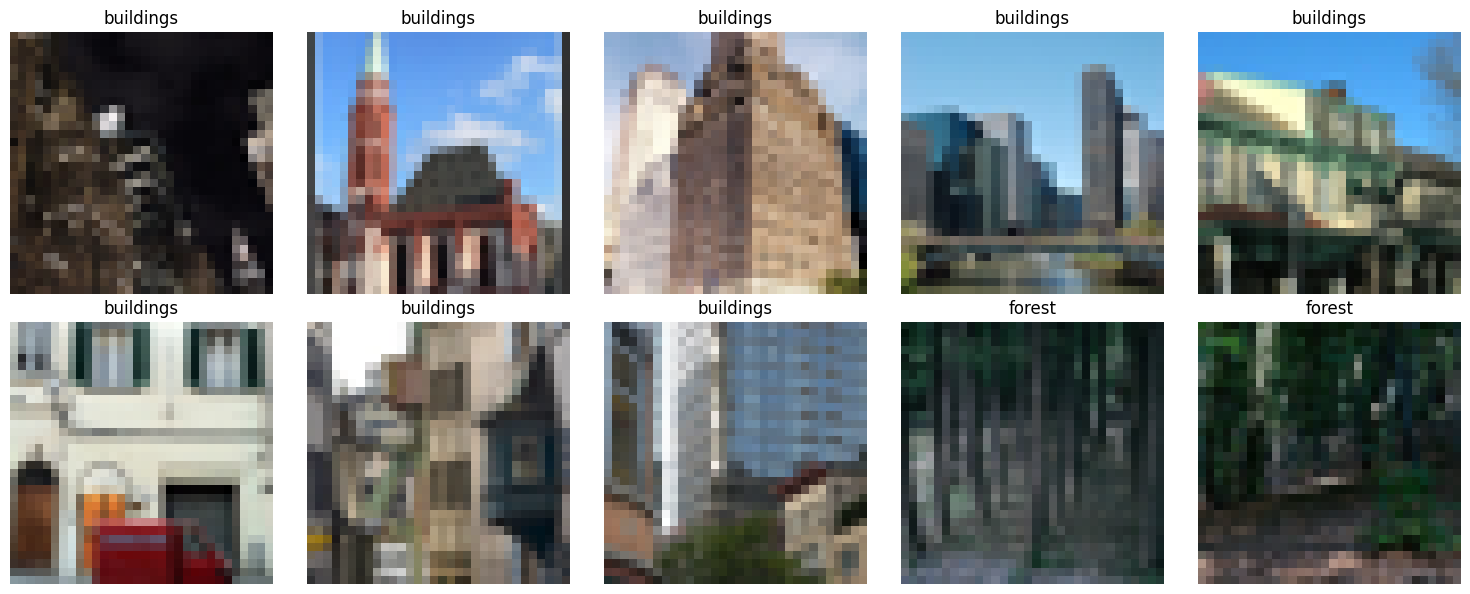

In [3]:
# Antes de entrenar cualquier modelo, siempre verifico visualmente los datos
# Si veo una montaña con etiqueta "forest", algo salió mal en la carga
# Este paso es simplemente inspección visual — no entrena nada

# Creo una cuadrícula de 2 filas x 5 columnas para ver 10 imágenes de muestra
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Recorro los 10 ejes de la cuadrícula uno a uno
for i, ax in enumerate(axes.flat):
    
    # Muestro imágenes saltando de 300 en 300 para ver distintas partes del dataset
    ax.imshow(X_train[i * 300])
    
    # Pongo como título el nombre de la clase (convierto el número 1 en "forest")
    ax.set_title(clases[y_train[i * 300]])
    
    # Oculto los ejes numéricos — no aportan nada en imágenes
    ax.axis('off')

# Ajusto automáticamente los espacios para que los títulos no se solapen
plt.tight_layout()
plt.show()

In [4]:
# Cada píxel de las imágenes tiene un valor entre 0 y 255
# Las redes neuronales funcionan mucho mejor con valores pequeños (entre 0 y 1)
# Simplemente divido entre 255 para conseguir ese rango

# También convierto a float32 porque por defecto las imágenes son uint8
# y las operaciones matemáticas necesitan punto flotante

X_train = X_train.astype("float32") / 255.0  # Train: de [0-255] a [0-1]
X_test  = X_test.astype("float32")  / 255.0  # Test:  de [0-255] a [0-1]

# IMPORTANTE: uso el mismo divisor (255) para train y test
# Nunca calculo estadísticas del test para normalizar — eso sería usar
# información que el modelo no debería ver (data leakage)

print("Rango de valores train:", X_train.min(), "-", X_train.max())  # Debería ser 0.0 - 1.0
print("Rango de valores test: ", X_test.min(),  "-", X_test.max())

Rango de valores train: 0.0 - 1.0
Rango de valores test:  0.0 - 1.0


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Calculo el número de clases automáticamente para no hardcodearlo
num_clases = len(clases)
print(f"Número de clases: {num_clases} → {clases}")

# Construyo la red neuronal de forma secuencial (capa tras capa)
# Es una CNN: Red Neuronal Convolucional, especializada en imágenes
modelo = models.Sequential([

    # --- BLOQUE 1: Primera detección de patrones visuales simples ---
    
    # Capa convolucional: 32 filtros de 3x3 que "deslizan" por la imagen
    # buscando patrones básicos: bordes, esquinas, cambios de color
    # input_shape le dice el tamaño de entrada: 32x32 píxeles, 3 canales RGB
    # relu es la función de activación: pone a 0 los valores negativos
    # sin relu, apilar capas no serviría de nada (todo seguiría siendo lineal)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    
    # MaxPooling: reduce la imagen a la mitad tomando el valor máximo de cada bloque 2x2
    # 32x32 → 16x16. Reduce cómputo y hace el modelo robusto a pequeños desplazamientos
    layers.MaxPooling2D((2, 2)),

    # --- BLOQUE 2: Detección de patrones más complejos ---
    
    # Segunda capa convolucional con 64 filtros (más que antes)
    # Ahora aprende combinaciones de patrones básicos: "bordes curvos + verde → hoja"
    # Más filtros = más capacidad para aprender patrones complejos
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Otro MaxPooling: 16x16 → 8x8. Sigue reduciendo dimensiones
    layers.MaxPooling2D((2, 2)),

    # --- PUENTE: de 2D a 1D ---
    
    # Flatten aplana el resultado 2D a un vector 1D
    # 8x8x64 = 4096 valores en un único vector
    # Es el puente entre la parte "visual" (Conv2D) y la parte "clasificadora" (Dense)
    layers.Flatten(),

    # --- CLASIFICADOR: aprende qué combinación de patrones es cada clase ---
    
    # Capa Dense: 128 neuronas, cada una conectada con los 4096 valores anteriores
    # Aquí la red aprende razonamiento de alto nivel:
    # "tiene agua + azul + horizonte → probablemente mar"
    layers.Dense(128, activation='relu'),
    
    # Dropout: durante el entrenamiento apaga aleatoriamente el 30% de las neuronas
    # Evita que la red memorice el train en vez de aprender patrones generales (overfitting)
    # Durante la predicción final no apaga nada
    layers.Dropout(0.3),
    
    # Capa de salida: una neurona por clase
    # softmax convierte los valores en probabilidades que suman 1
    # Ejemplo con 6 clases: [0.02, 0.80, 0.03, 0.05, 0.07, 0.03] → clase 1 con 80%
    layers.Dense(num_clases, activation='softmax')
])

# Configuro cómo se va a entrenar el modelo
modelo.compile(
    optimizer='adam',                        # Algoritmo que ajusta los pesos. Adam se adapta automáticamente al ritmo de aprendizaje
    loss='sparse_categorical_crossentropy',  # Mide cuánto se equivoca. "sparse" porque mis etiquetas son enteros (0,1,2...) no vectores
    metrics=['accuracy']                     # Métrica a mostrar: porcentaje de imágenes clasificadas correctamente
)

# Muestro un resumen de la arquitectura: capas, dimensiones y número de parámetros (pesos)
modelo.summary()

Número de clases: 6 → ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                    

In [6]:
# Entreno el modelo con los datos de train
# El modelo verá las imágenes, comparará su predicción con la etiqueta real
# y ajustará sus pesos para equivocarse menos en la próxima vuelta

history = modelo.fit(
    X_train, y_train,      # Los datos de entrenamiento: imágenes y sus etiquetas
    epochs=15,             # El modelo verá todos los datos 15 veces (15 "vueltas completas")
    batch_size=64,         # En vez de actualizar pesos tras cada imagen, agrupa 64 de golpe
                           # Más eficiente y el aprendizaje es más estable
    validation_split=0.2   # Reserva el 20% de train para validación
                           # Este 20% NO se usa para entrenar, solo para detectar overfitting
)

# history guarda el accuracy y la loss de cada época
# Lo usaré en la siguiente celda para graficar cómo ha aprendido el modelo

Epoch 1/15
176/176 [==============================] - 2s 11ms/step - loss: 1.0760 - accuracy: 0.5698 - val_loss: 7.4667 - val_accuracy: 0.0663
Epoch 2/15
176/176 [==============================] - 2s 12ms/step - loss: 0.8248 - accuracy: 0.6799 - val_loss: 9.4344 - val_accuracy: 0.0249
Epoch 3/15
176/176 [==============================] - 2s 11ms/step - loss: 0.7449 - accuracy: 0.7216 - val_loss: 10.3020 - val_accuracy: 0.0609
Epoch 4/15
176/176 [==============================] - 2s 11ms/step - loss: 0.6875 - accuracy: 0.7451 - val_loss: 9.8985 - val_accuracy: 0.1055
Epoch 5/15
176/176 [==============================] - 2s 10ms/step - loss: 0.6575 - accuracy: 0.7586 - val_loss: 10.1426 - val_accuracy: 0.0941
Epoch 6/15
176/176 [==============================] - 2s 11ms/step - loss: 0.6041 - accuracy: 0.7844 - val_loss: 10.7838 - val_accuracy: 0.0908
Epoch 7/15
176/176 [==============================] - 2s 13ms/step - loss: 0.5814 - accuracy: 0.7876 - val_loss: 10.4354 - val_accuracy: 0.

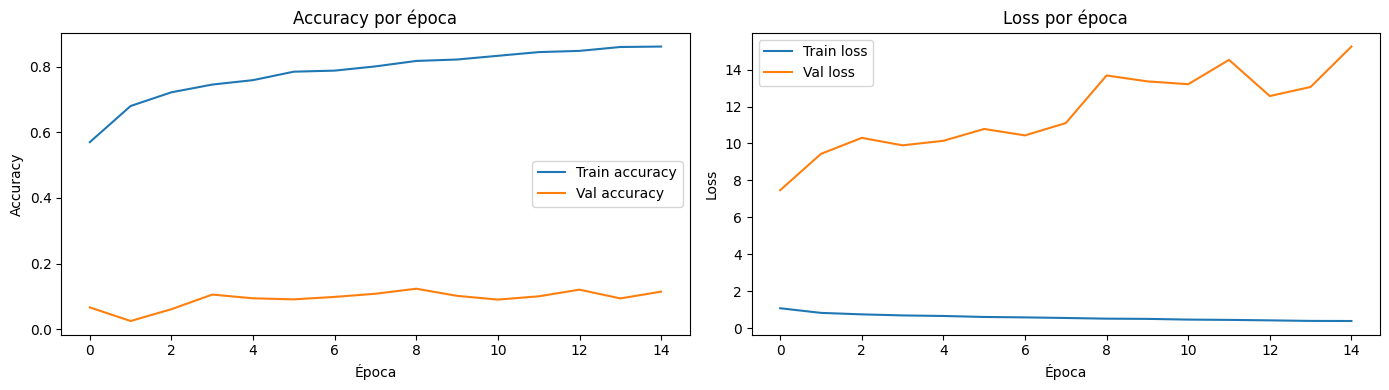

In [7]:
# Grafico cómo ha evolucionado el entrenamiento época a época
# Es el diagnóstico más importante: me dice si el modelo aprendió bien o hay problemas

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# --- Gráfica de Accuracy (izquierda) ---
ax1.plot(history.history['accuracy'],     label='Train accuracy')  # Accuracy en datos de entrenamiento
ax1.plot(history.history['val_accuracy'], label='Val accuracy')    # Accuracy en datos de validación
ax1.set_title('Accuracy por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()
# Si ambas curvas suben juntas → el modelo aprende bien
# Si train sube pero val se estanca o baja → overfitting (memoriza en vez de aprender)

# --- Gráfica de Loss (derecha) ---
ax2.plot(history.history['loss'],     label='Train loss')  # Error en datos de entrenamiento
ax2.plot(history.history['val_loss'], label='Val loss')    # Error en datos de validación
ax2.set_title('Loss por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
# La loss debe bajar con el tiempo
# Si la loss de val sube mientras la de train baja → overfitting claro

plt.tight_layout()
plt.show()

In [8]:
# Evalúo el modelo con datos que NUNCA ha visto durante el entrenamiento
# La validación del paso anterior se usó indirectamente para tomar decisiones
# El test es completamente nuevo — su accuracy es la medida más honesta del modelo

loss, acc = modelo.evaluate(X_test, y_test, verbose=1)

print(f"\nTest accuracy: {acc:.4f}")  # Porcentaje de imágenes clasificadas correctamente
print(f"Test loss:     {loss:.4f}")   # Cuánto se equivoca en promedio

94/94 [==============================] - 0s 2ms/step - loss: 3.3304 - accuracy: 0.6730

Test accuracy: 0.6730
Test loss:     3.3304


In [9]:
# ME ESTÁ SALIENDO UN OVERFITTING BESTIAL, ENTONCES, TENGO QUE VOLVER A EMPEZAR. PIDO AYUDA A CLAUDE Y ME DICE QUE PUEDE SER PORQUE:
# "Probablemente tengo imágenes con 4 canales RGBA (Rojo, Verde, Azul, Alpha/transparencia) mezcladas con imágenes de 3 canales RGB.
# Eso corrompe el array y hace que el modelo no pueda aprender nada real". 

# Vuelvo a cargar las imágenes, pero esta vez convierto todas a RGB para asegurarme de que no haya canales extraños:

In [10]:
ruta_base = "/Users/andoni/Desktop/clasificador_paisajes"
ruta_training = "/Users/andoni/Desktop/clasificador_paisajes/seg_train"
ruta_test = "/Users/andoni/Desktop/clasificador_paisajes/seg_test"

In [11]:
# Importo las librerías que necesito para este ejercicio
import os              # Para navegar por las carpetas del sistema
import numpy as np     # Para manejar las imágenes como matrices de números
from PIL import Image  # Para abrir y redimensionar archivos de imagen
import matplotlib.pyplot as plt  # Para visualizar imágenes y gráficas


# Defino el tamaño al que voy a redimensionar todas las imágenes
# Uso 32x32 para que el entrenamiento sea más rápido
# La red neuronal necesita que todas las imágenes tengan el mismo tamaño
IMG_SIZE = (32, 32)

def cargar_imagenes(ruta_base):
    # Inicializo listas vacías donde iré acumulando los datos
    X = []       # Aquí guardaré cada imagen convertida en números
    y = []       # Aquí guardaré la etiqueta numérica de cada imagen (0, 1, 2...)
    clases = []  # Aquí guardaré los nombres de las categorías

    # Listo las subcarpetas — cada subcarpeta es una clase ("forest", "mountain"...)
    # sorted() las ordena alfabéticamente para que el índice sea siempre el mismo
    clases = sorted(os.listdir(ruta_base))

    # Filtro archivos ocultos que macOS crea automáticamente (.DS_Store, etc.)
    clases = [c for c in clases if not c.startswith('.')]

    # Recorro cada clase con su índice numérico
    # enumerate me da el índice (0, 1, 2...) y el nombre ("forest"...) a la vez
    for idx, clase in enumerate(clases):

        # Construyo la ruta completa a la subcarpeta de esta clase
        carpeta = os.path.join(ruta_base, clase)

        # Recorro cada archivo de imagen dentro de la subcarpeta
        for archivo in os.listdir(carpeta):

            # Construyo la ruta completa al archivo de imagen
            ruta_img = os.path.join(carpeta, archivo)

            # Uso try/except para que si una imagen está corrupta
            # el programa simplemente la salte y continúe con la siguiente
            try:
                # .convert("RGB") es el arreglo clave:
                # Algunas imágenes tienen 4 canales (RGBA: Rojo, Verde, Azul, Alpha/transparencia)
                # o son en escala de grises (1 canal). Si las mezclo con imágenes de 3 canales (RGB)
                # el array queda corrupto y el modelo no puede aprender nada.
                # .convert("RGB") fuerza TODAS las imágenes a exactamente 3 canales RGB
                # independientemente del formato original — esto soluciona el overfitting severo
                img = Image.open(ruta_img).convert("RGB").resize(IMG_SIZE)

                # Convierto la imagen en un array numpy de forma (32, 32, 3)
                # El 3 son los 3 canales de color: Rojo, Verde, Azul
                X.append(np.array(img))

                # Guardo el índice numérico de la clase como etiqueta
                # Si estoy en "forest" con idx=1, guardo el número 1
                y.append(idx)

            except:
                # Si algo falla con la imagen, la ignoro silenciosamente
                pass

    # Convierto las listas a arrays numpy para poder usarlos con la red neuronal
    # X tendrá forma (num_imágenes, 32, 32, 3)
    # y tendrá forma (num_imágenes,) — un número de clase por imagen
    return np.array(X), np.array(y), clases

# Llamo a la función dos veces: una para train y otra para test
# El _ en la segunda llamada significa "no necesito las clases aquí, ya las tengo"
X_train, y_train, clases = cargar_imagenes(ruta_training)
X_test,  y_test,  _      = cargar_imagenes(ruta_test)

# Compruebo que las dimensiones son correctas
# X_train debe ser (N, 32, 32, 3) — si el último número no es 3, hay imágenes con canales distintos
print("Clases encontradas:", clases)
print("Forma X_train:", X_train.shape)
print("Forma X_test: ", X_test.shape)

Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Forma X_train: (14034, 32, 32, 3)
Forma X_test:  (3000, 32, 32, 3)


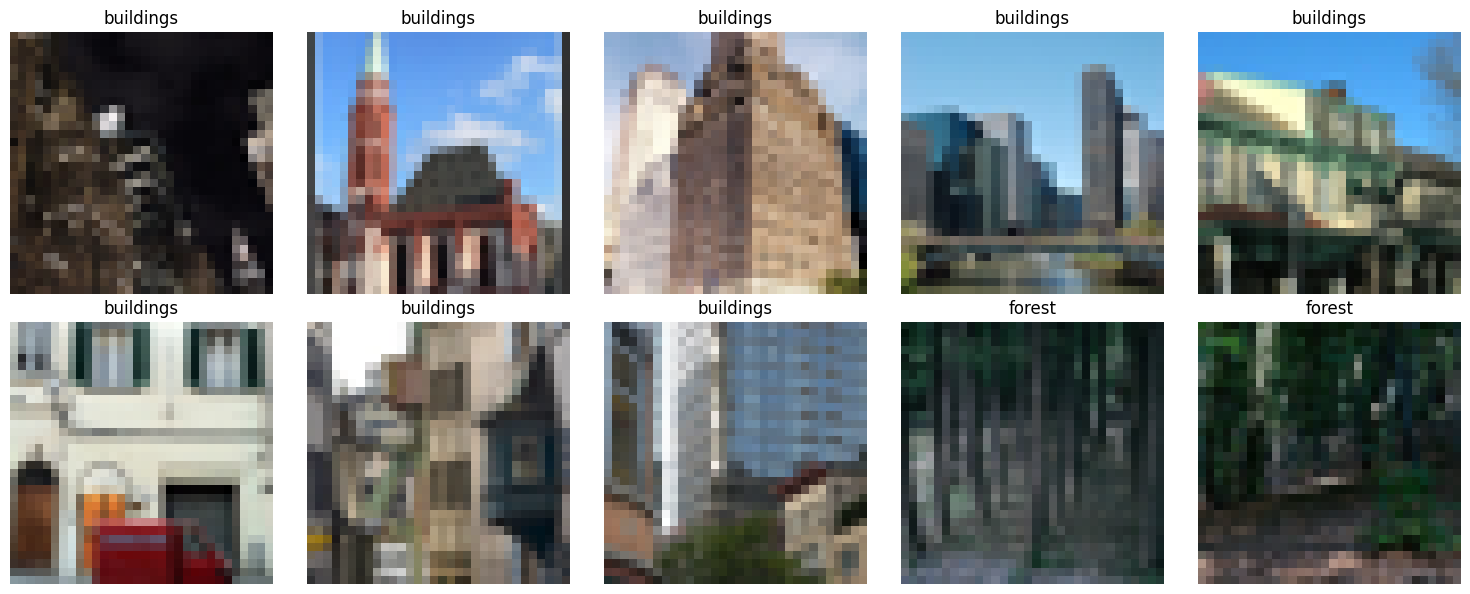

In [12]:
# Antes de entrenar cualquier modelo, siempre verifico visualmente los datos
# Si veo una montaña con etiqueta "forest", algo salió mal en la carga
# Este paso es solo inspección visual — no entrena nada

# Creo una cuadrícula de 2 filas x 5 columnas para ver 10 imágenes de muestra
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Recorro los 10 ejes de la cuadrícula uno a uno
for i, ax in enumerate(axes.flat):

    # Muestro imágenes saltando de 300 en 300 para ver distintas partes del dataset
    ax.imshow(X_train[i * 300])

    # Pongo como título el nombre de la clase (convierto el número 1 en "forest")
    ax.set_title(clases[y_train[i * 300]])

    # Oculto los ejes numéricos — no aportan nada en imágenes
    ax.axis('off')

# Ajusto automáticamente los espacios para que los títulos no se solapen
plt.tight_layout()
plt.show()

In [13]:
# Cada píxel tiene un valor entre 0 y 255
# Las redes neuronales funcionan mucho mejor con valores pequeños entre 0 y 1
# Simplemente divido entre 255 para conseguir ese rango

# astype("float32") convierte de enteros (uint8) a decimales, necesario para dividir
X_train = X_train.astype("float32") / 255.0  # Train: de [0-255] a [0-1]
X_test  = X_test.astype("float32")  / 255.0  # Test:  de [0-255] a [0-1]

# IMPORTANTE: uso el mismo divisor (255) para train y test
# Nunca calculo estadísticas del test para normalizar — eso sería usar
# información que el modelo no debería ver (data leakage)

print("Rango de valores train:", X_train.min(), "-", X_train.max())  # Debe ser 0.0 - 1.0
print("Rango de valores test: ", X_test.min(),  "-", X_test.max())

Rango de valores train: 0.0 - 1.0
Rango de valores test:  0.0 - 1.0


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Calculo el número de clases automáticamente para no hardcodearlo
num_clases = len(clases)
print(f"Número de clases: {num_clases} → {clases}")

# Construyo la red neuronal de forma secuencial (capa tras capa)
# Es una CNN: Red Neuronal Convolucional, especializada en clasificar imágenes
modelo = models.Sequential([

    # --- BLOQUE 1: Detección de patrones visuales simples ---

    # 32 filtros de 3x3 "deslizan" por la imagen buscando bordes, esquinas, texturas
    # input_shape le dice el tamaño de entrada: 32x32 píxeles, 3 canales RGB
    # relu pone a 0 los valores negativos — sin esto apilar capas no serviría de nada
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),

    # MaxPooling reduce la imagen a la mitad tomando el máximo de cada bloque 2x2
    # 32x32 → 16x16. Reduce cómputo y hace el modelo robusto a pequeños desplazamientos
    layers.MaxPooling2D((2, 2)),

    # --- BLOQUE 2: Detección de patrones más complejos ---

    # 64 filtros (más que antes) para aprender combinaciones de patrones:
    # "borde curvo + textura verde → posiblemente hoja de árbol"
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Otro MaxPooling: 16x16 → 8x8. Sigue reduciendo dimensiones
    layers.MaxPooling2D((2, 2)),

    # --- PUENTE: de 2D a 1D ---

    # Flatten aplana el resultado 2D (8x8x64=4096 valores) en un vector 1D
    # Es el puente entre la parte "visual" (Conv2D) y la parte "clasificadora" (Dense)
    layers.Flatten(),

    # --- CLASIFICADOR ---

    # 128 neuronas, cada una conectada con los 4096 valores anteriores
    # Aquí la red aprende: "agua + azul + horizonte → probablemente mar"
    layers.Dense(128, activation='relu'),
    
     #64 neuronas, cada una conectada con los 4096 valores anteriores
    # Aquí la red aprende: "agua + azul + horizonte → probablemente mar"
    layers.Dense(64, activation='relu'),
    
    #32 neuronas, cada una conectada con los 4096 valores anteriores
    # Aquí la red aprende: "agua + azul + horizonte → probablemente mar"
    layers.Dense(32, activation='relu'),
    
    
    

    # Dropout: apaga aleatoriamente el 30% de neuronas durante el entrenamiento
    # Evita que la red memorice el train en vez de aprender (previene overfitting)
    # Durante la predicción final no apaga nada
    layers.Dropout(0.3),

    # Capa de salida: una neurona por clase
    # softmax convierte los valores en probabilidades que suman 1
    # Ejemplo: [0.02, 0.80, 0.03, 0.05, 0.07, 0.03] → clase 1 con 80% de probabilidad
    layers.Dense(num_clases, activation='softmax')
])

# Configuro cómo se va a entrenar el modelo
modelo.compile(
    optimizer='adam',                        # Algoritmo que ajusta los pesos automáticamente
    loss='sparse_categorical_crossentropy',  # Mide cuánto se equivoca. "sparse" porque mis etiquetas son enteros (0,1,2...)
    metrics=['accuracy']                     # Métrica a mostrar: % de imágenes clasificadas correctamente
)

# Muestro un resumen de la arquitectura: capas, dimensiones y número de parámetros
modelo.summary()

Número de clases: 6 → ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 2304)              0         
                                  

In [15]:
# Entreno el modelo con los datos de train
# En cada época el modelo ve todas las imágenes, compara su predicción con la etiqueta real
# y ajusta sus pesos internos para equivocarse menos en la siguiente vuelta

history = modelo.fit(
    X_train, y_train,    # Los datos: imágenes y sus etiquetas numéricas
    epochs=15,           # El modelo verá todos los datos 15 veces completas
    batch_size=128,       # Agrupa 64 imágenes antes de actualizar los pesos
                         # Más eficiente que actualizar tras cada imagen
    validation_split=0.2 # Reserva el 20% de train para validación
                         # Este 20% NO se usa para entrenar — solo para detectar overfitting
)

# history guarda accuracy y loss de cada época — lo uso en la siguiente celda para graficar
# Señales de un entrenamiento sano:
# - train accuracy y val accuracy suben juntas
# - train loss y val loss bajan juntas
# Señal de overfitting (lo que tenía antes del arreglo):
# - train accuracy muy alta, val accuracy muy baja
# - val loss sube mientras train loss baja

Epoch 1/15
88/88 [==============================] - 2s 24ms/step - loss: 1.2572 - accuracy: 0.4977 - val_loss: 5.1630 - val_accuracy: 0.0057
Epoch 2/15
88/88 [==============================] - 2s 24ms/step - loss: 0.9358 - accuracy: 0.6381 - val_loss: 6.3249 - val_accuracy: 0.0937
Epoch 3/15
88/88 [==============================] - 2s 23ms/step - loss: 0.8291 - accuracy: 0.6935 - val_loss: 6.2958 - val_accuracy: 0.1097
Epoch 4/15
88/88 [==============================] - 2s 25ms/step - loss: 0.7776 - accuracy: 0.7183 - val_loss: 7.1826 - val_accuracy: 0.0898
Epoch 5/15
88/88 [==============================] - 2s 25ms/step - loss: 0.6947 - accuracy: 0.7497 - val_loss: 7.0932 - val_accuracy: 0.0730
Epoch 6/15
88/88 [==============================] - 2s 25ms/step - loss: 0.6586 - accuracy: 0.7675 - val_loss: 7.1142 - val_accuracy: 0.0948
Epoch 7/15
88/88 [==============================] - 2s 22ms/step - loss: 0.6128 - accuracy: 0.7895 - val_loss: 7.3754 - val_accuracy: 0.0752
Epoch 8/15
88

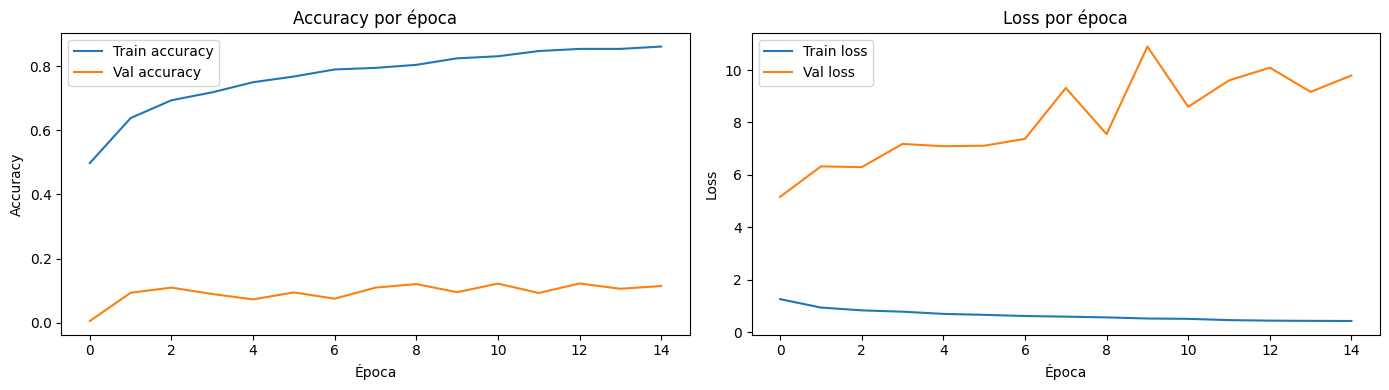

In [16]:
# Grafico cómo ha evolucionado el entrenamiento época a época
# Es el diagnóstico más importante: me dice si el modelo aprendió bien o hay problemas

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# --- Gráfica de Accuracy (izquierda) ---
# Si ambas curvas suben juntas → el modelo aprende bien
# Si train sube pero val se estanca o baja → overfitting
ax1.plot(history.history['accuracy'],     label='Train accuracy')
ax1.plot(history.history['val_accuracy'], label='Val accuracy')
ax1.set_title('Accuracy por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()

# --- Gráfica de Loss (derecha) ---
# La loss debe bajar con el tiempo en ambas curvas
# Si val_loss sube mientras train_loss baja → overfitting claro
ax2.plot(history.history['loss'],     label='Train loss')
ax2.plot(history.history['val_loss'], label='Val loss')
ax2.set_title('Loss por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()